<img style="float:left" width="70%" src="pics/escudo_COLOR_1L_DCHA.png">
<img style="float:right" width="15%" src="pics/PythonLogo.svg">
<br style="clear:both;">

<h2 style="display: inline-block; padding: 4mm; padding-left: 2em; background-color: navy; line-height: 1.3em; color: white; border-radius: 10px;">Contornos activos para segmentación.</h2>

### Contornos activos y *Morphological Snakes*
#### Author: Pedro Latorre Carmonaç

### Alumno: Pablo Fernández Gumiel

##### Curso 2025-2026

Versión 1.0

---

# Práctica 3: Segmentación Avanzada con Modelos Deformables
### Grado en Ingeniería Biomédica - Visión por Computador

---

## Índice de la Práctica

1.  **Configuración e Introducción:** Librerías y conceptos básicos.
2.  **Active Contours (Snakes Paramétricos):**
    * Estudio de parámetros ($\alpha, \beta$) en topología compleja (Estrella de mar).
    * Aplicación médica: Segmentación de nódulo en ecografía.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from scipy import ndimage as ndi
from itertools import cycle
from sklearn.metrics import confusion_matrix

# ACTIVE CONTOURS

## 2. Parte A: Active Contours (Snakes Paramétricos)

### Fundamento Teórico: La Energía del Snake
Un *Active Contour* o Snake se define como una curva paramétrica $v(s) = (x(s), y(s))$ que intenta minimizar un funcional de energía $E_{snake} = E_{int} + E_{ext}$.

Para entender su comportamiento, debemos diseccionar sus componentes internos, controlados por dos hiperparámetros críticos que vamos a estudiar:

1.  **Energía Interna (Regularización geométrica):**
    * **Continuidad ($\alpha$ - Alpha):** Penaliza el estiramiento de la curva. Un $\alpha$ alto actúa como una banda elástica muy tensa, contrayendo el snake rápidamente.
    * **Suavidad ($\beta$ - Beta):** Penaliza la curvatura (la segunda derivada). Un $\beta$ alto hace que el snake se comporte como una varilla metálica rígida, resistiéndose a doblarse en esquinas agudas.

2.  **Energía Externa (Atracción de datos):**
    * Atrae al snake hacia características de la imagen, generalmente gradientes altos (bordes).

In [ ]:
# --- Código para calcular las métricas de las pruebas de Active Contours---

# --- Convertir el contorno del Snake (puntos) a Máscara Binaria (imagen) ---
def snake_to_mask(snake, image_shape):
    """
    Convierte la lista de coordenadas (r, c) del snake en una máscara booleana rellena.
    """
    mask = np.zeros(image_shape, dtype=bool)
    # Asegurarse de que las coordenadas estén dentro de la imagen
    r = np.clip(snake[:, 0], 0, image_shape[0] - 1)
    c = np.clip(snake[:, 1], 0, image_shape[1] - 1)
    
    # Crear polígono relleno
    rr, cc = polygon(r, c, image_shape)
    mask[rr, cc] = True
    return mask

# --- Calcular Métricas (Precisión, Sensibilidad, Especificidad) ---
def calculate_metrics(ground_truth, prediction):
    """
    Compara la máscara real (GT) con la predicción y devuelve métricas.
    """
    # Aplanar arrays para la matriz de confusión
    gt = ground_truth.flatten().astype(bool)
    pred = prediction.flatten().astype(bool)
    
    # Calcular matriz de confusión (True Negative, False Positive, etc.)
    tn, fp, fn, tp = confusion_matrix(gt, pred, labels=[False, True]).ravel()
    
    # Calcular métricas
    # Sensibilidad (Recall): ¿Cuánto del objeto real capturamos?
    sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # Especificidad: ¿Qué tan bien ignoramos el fondo?
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Precisión: De lo que capturamos, ¿cuánto es realmente objeto?
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    return sensibilidad, especificidad, precision

## Matriz de Comportamiento ($\alpha$ vs $\beta$) en la imagen de la estrella de mar
Vamos a segmentar una **Estrella de Mar**, una estructura topológicamente desafiante por poseer **puntas agudas** (alta curvatura) y **concavidades profundas**.
Se realiza un *Grid Search* (búsqueda en rejilla) de 5x5, variando $\alpha$ y $\beta$ logarítmicamente, para visualizar empíricamente cómo la física del snake afecta a la segmentación final.

Ejecutando Matriz de Geometría (Alpha vs Beta)...


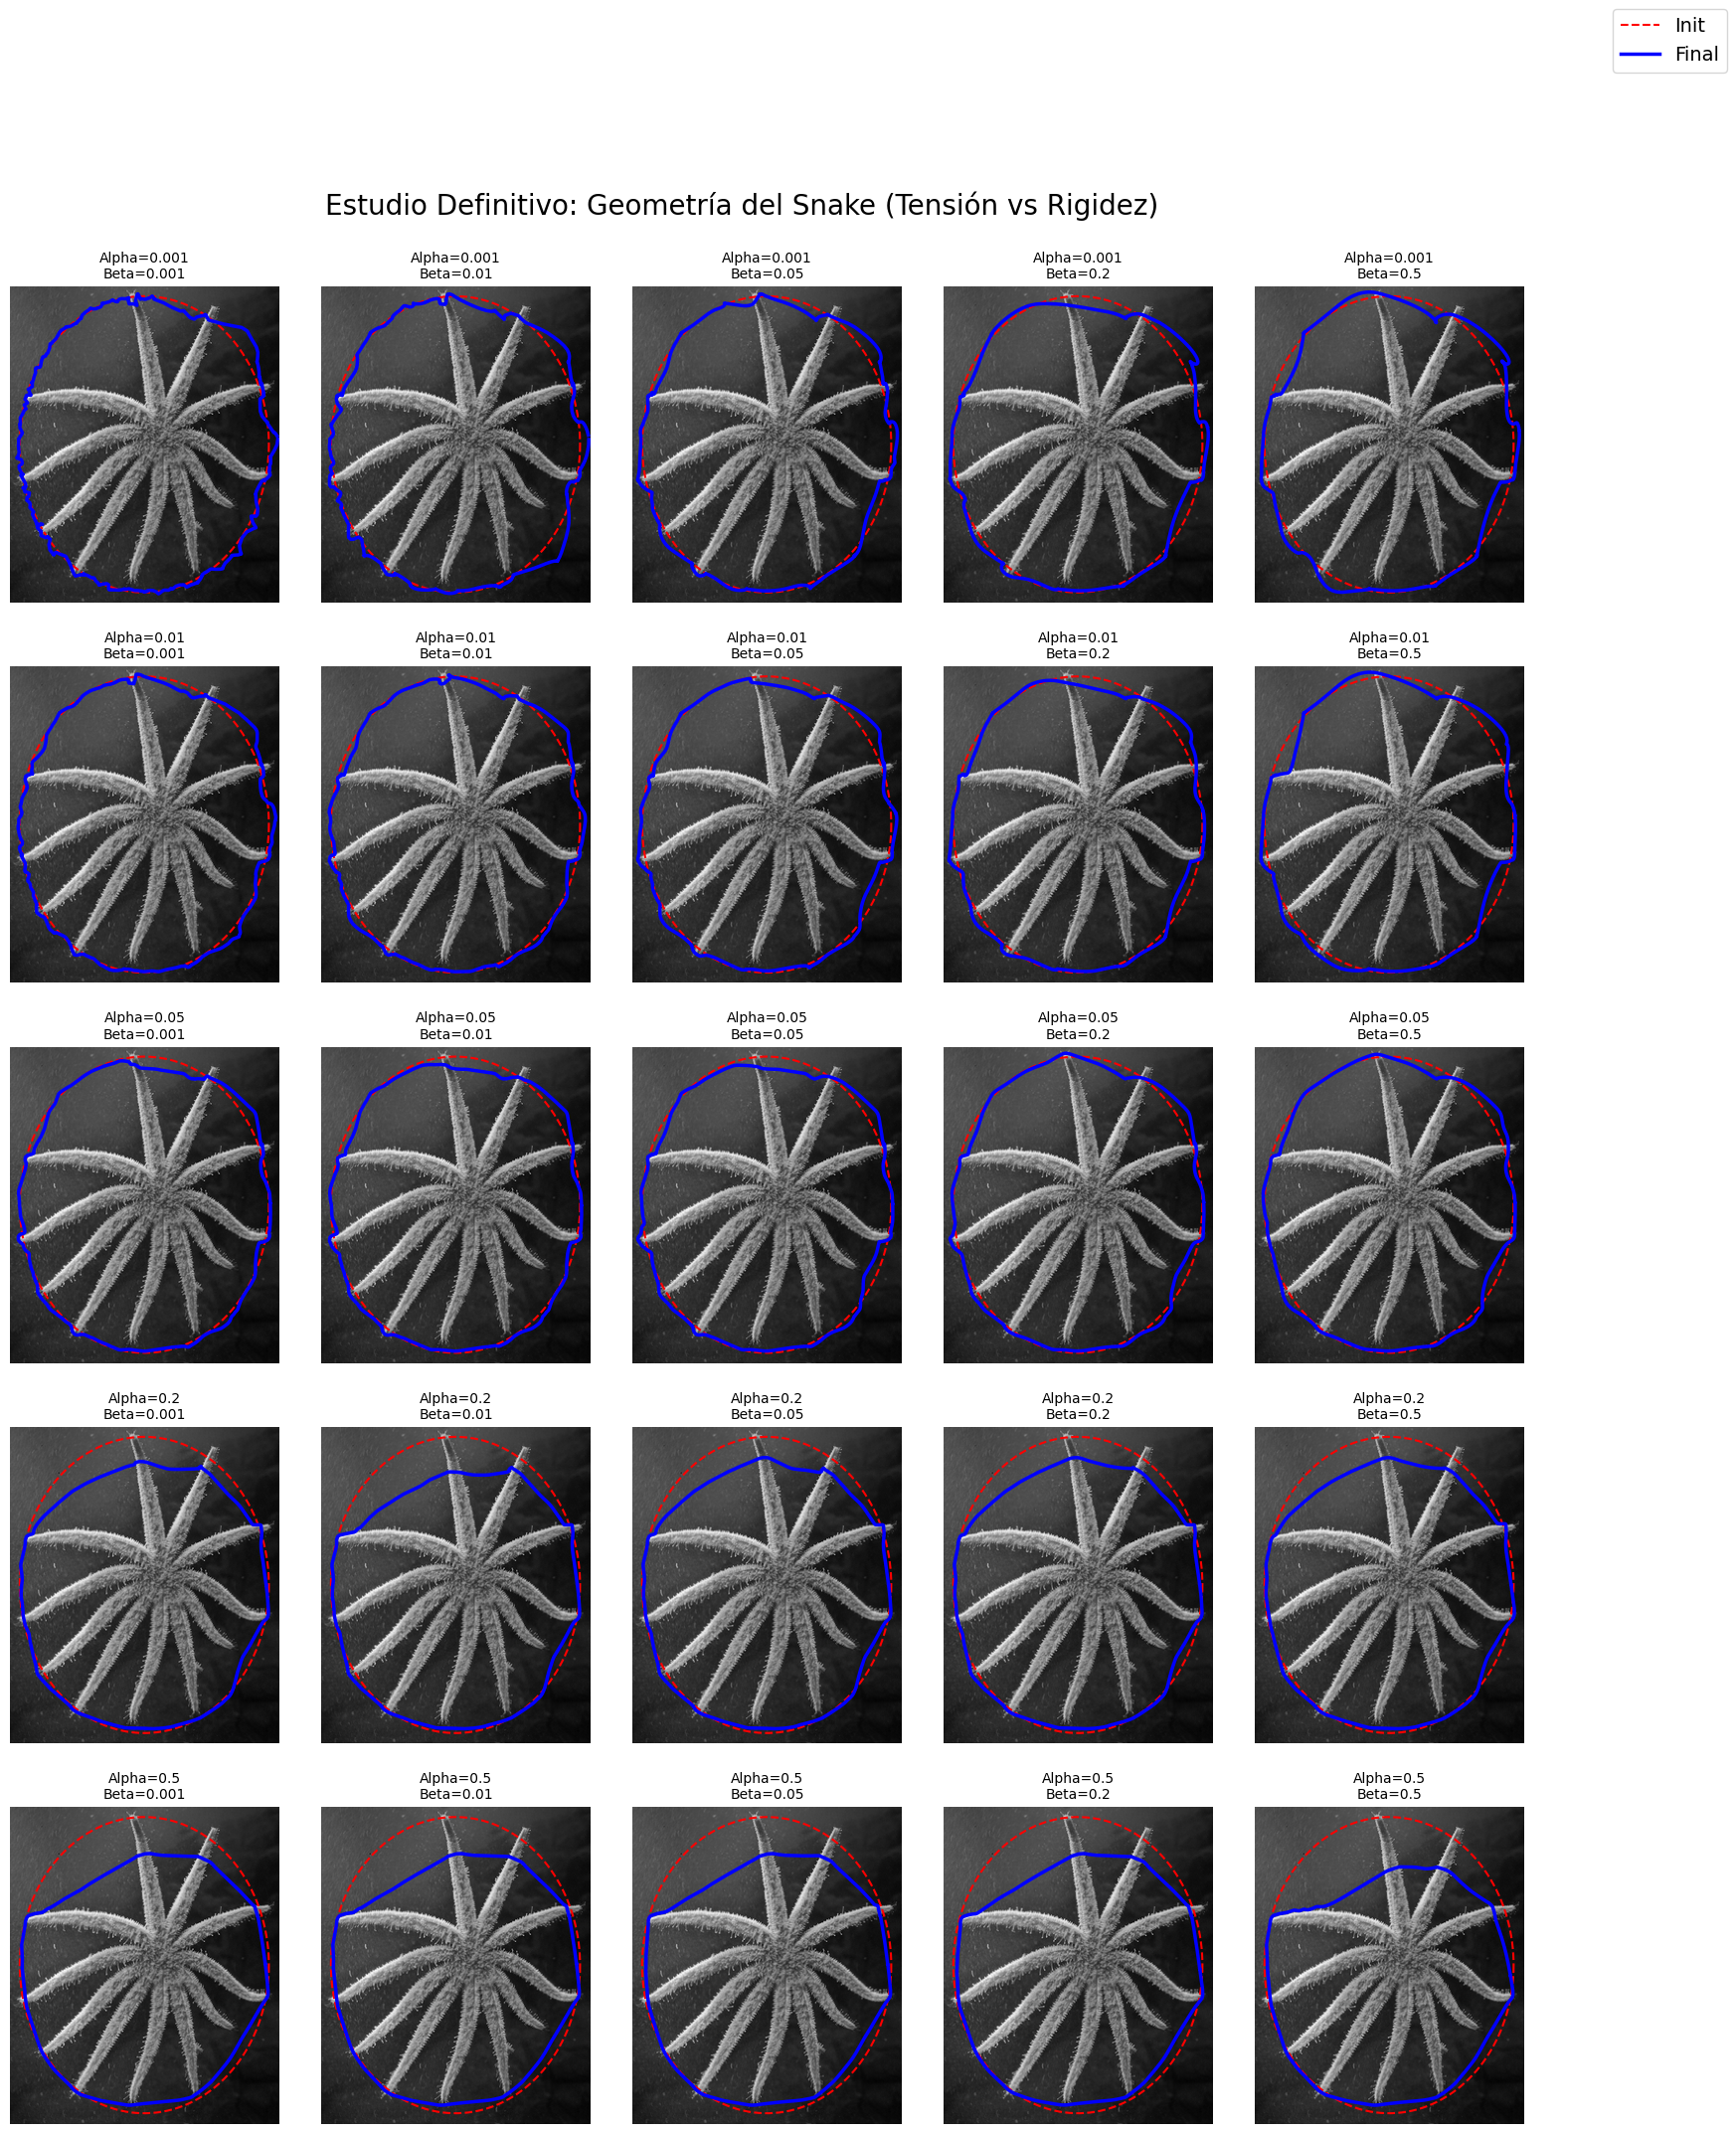

In [15]:
# --- 1. CONFIGURACIÓN ---
img_path = 'images/seastar2.png'
img = io.imread(img_path)
if len(img.shape) > 2: img = color.rgb2gray(img)
img = img_as_float(img)
img_smooth = gaussian(img, 1) # Suavizado ligero
rows, cols = img.shape

# --- 2. INICIALIZACIÓN (Shrinking Snake) ---
# Círculo grande que cubre casi toda la imagen
s = np.linspace(0, 2*np.pi, 600)
r = rows//2 + (rows//2 - 10)*np.sin(s)
c = cols//2 + (cols//2 - 10)*np.cos(s)
init = np.array([r, c]).T

# --- 3. MATRIZ DE PRUEBAS (5x5) ---
# Alphas (Filas): De "Relajado" a "Muy Tenso"
alphas = [0.001, 0.01, 0.05, 0.2, 0.5] 

# Betas (Columnas): De "Líquido" a "Acero"
betas = [0.001, 0.01, 0.05, 0.2, 0.5]

# Configurar figura GRANDE para ver detalles
fig, axes = plt.subplots(5, 5, figsize=(20, 24), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.2)

print("Ejecutando Matriz de Geometría (Alpha vs Beta)...")

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        ax = axes[i, j]
        
        # PARAMETROS FIJOS DE ATRACCIÓN:
        # w_line = -2: Atracción fuerte al blanco (estrella)
        # w_edge = 2: Atracción a los bordes
        # Iteraciones altas para permitir que llegue desde el borde
        snake = active_contour(img_smooth, 
                               init, 
                               alpha=alpha, 
                               beta=beta, 
                               w_line=-2.0, 
                               w_edge=2.0, 
                               gamma=0.01, 
                               max_num_iter=2500)
        
        ax.imshow(img, cmap='gray')
        
        # Dibujar inicial (Rojo)
        ax.plot(init[:, 1], init[:, 0], '--r', lw=1.5, label='Init')
        
        # Dibujar final (Azul)
        ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2.5, label='Final')
        
        # Fijar límites para evitar zoom automático y mantener uniformidad
        ax.set_xlim(0, cols)
        ax.set_ylim(rows, 0)
        
        # Títulos descriptivos
        ax.set_title(f"Alpha={alpha}\nBeta={beta}", fontsize=10)
        ax.axis('off')

# Título general y leyenda
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=14)
plt.suptitle("Estudio Definitivo: Geometría del Snake (Tensión vs Rigidez)", y=0.92, fontsize=20)
plt.show()

In [ ]:
img_star = img_as_float(color.rgb2gray(io.imread('images/seastar2.png')))
mask_star_gt = io.imread('images/Mascara_estrella.png', as_gray=True) > 0.5 # Convertir a booleano

# Preprocesamiento
img_star_smooth = gaussian(img_star, 2)

# Inicialización
s = np.linspace(0, 2*np.pi, 400)
r = 100 + 100*np.sin(s)
c = 220 + 100*np.cos(s)
init_snake = np.array([r, c]).T

# --- GRID SEARCH DE PARÁMETROS ---
alphas = [0.001, 0.01, 0.05, 0.2, 0.5]
betas = [0.001, 0.01, 0.05, 0.2, 0.5]


print("Métricas con diferentes valores de alpha y beta para Estrella")
print(f"{'Alpha':^7} | {'Beta':^7} | {'Sensib.':^7} | {'Especif.':^7} | {'Precis.':^7}")
print("-" * 55)

for alpha in alphas:
    for beta in betas:
        # Ejecutar Active Contour
        snake = active_contour(img_star_smooth, init_snake, alpha=alpha, beta=beta, w_line=0, w_edge=1, gamma=0.001)
        
        # Convertir a máscara
        mask_pred = snake_to_mask(snake, img_star.shape)
        
        # Calcular métricas
        sens, spec, prec = calculate_metrics(mask_star_gt, mask_pred)
        
        print(f"{alpha:^7.3f} | {beta:^7.3f} | {sens:^7.3f} | {spec:^7.3f} | {prec:^7.3f}")

Métricas con diferentes valores de alpha y beta para Estrella
 Alpha  |  Beta   | Sensib. | Especif. | Precis.
-------------------------------------------------------
 0.001  |   0.0   |  0.410  |  0.871  |  0.496 
 0.001  |   0.0   |  0.391  |  0.894  |  0.534 
 0.001  |   0.1   |  0.389  |  0.887  |  0.516 
 0.001  |   0.2   |  0.371  |  0.892  |  0.514 
 0.001  |   0.5   |  0.384  |  0.880  |  0.496 
 0.010  |   0.0   |  0.351  |  0.917  |  0.568 
 0.010  |   0.0   |  0.355  |  0.917  |  0.569 
 0.010  |   0.1   |  0.253  |  0.919  |  0.491 
 0.010  |   0.2   |  0.257  |  0.910  |  0.470 
 0.010  |   0.5   |  0.235  |  0.922  |  0.481 
 0.050  |   0.0   |  0.237  |  0.927  |  0.502 
 0.050  |   0.0   |  0.233  |  0.931  |  0.510 
 0.050  |   0.1   |  0.243  |  0.928  |  0.512 
 0.050  |   0.2   |  0.242  |  0.930  |  0.518 
 0.050  |   0.5   |  0.209  |  0.932  |  0.486 
 0.200  |   0.0   |  0.126  |  0.982  |  0.684 
 0.200  |   0.0   |  0.128  |  0.981  |  0.670 
 0.200  |   0.1  

## Análisis de Resultados: El Compromiso Elasticidad-Rigidez en el caso de la Estrella de Mar

La matriz de imágenes generada arriba es fundamental para entender las limitaciones de los snakes paramétricos. Analicemos los extremos:

* **Región Superior Izquierda (Bajo $\alpha$, Bajo $\beta$):** El snake tiene poca tensión y rigidez. **Resultado:** Inestabilidad. La curva se vuelve rugosa y se ancla a texturas irrelevantes del fondo (arena), sufriendo de *sobreajuste*.
* **Región Inferior (Alto $\alpha$):** La tensión es excesiva. **Resultado:** Colapso. La fuerza elástica supera a la atracción de los bordes, haciendo que el snake se encoja hasta convertirse en un punto o un polígono minúsculo, ignorando la forma de la estrella.
* **Región Derecha (Alto $\beta$):** La rigidez es dominante. **Resultado:** Falta de detalle. El snake no puede doblarse lo suficiente para entrar en las "axilas" entre los brazos de la estrella ni para formar las puntas afiladas, resultando en una forma casi circular.

**Conclusión:** La segmentación óptima se encuentra en la **diagonal central**, donde existe un equilibrio: suficiente flexibilidad para entrar en las concavidades, pero suficiente tensión para mantener la coherencia de la forma y no perderse en el ruido. Lo que vemos es que claramente este método no es eficaz para la segmentacion de estructuras complejas como es el caso de una estrella ya que se ve que no es capaz de aproximarse a las estructuras.

## Matriz de Comportamiento ($\alpha$ vs $\beta$) en la imagen de los lagos
Tras hacer la prueba con la imagen de la **Estrella de Mar** vamos a relizar las mismas pruebas sobre la imagen de **Los Lagos**, una estructura compleja por ser varias masas de agua separadas entre si.

Se realiza un *Grid Search* (búsqueda en rejilla) de 5x5, variando $\alpha$ y $\beta$ logarítmicamente, para visualizar empíricamente cómo la física del snake afecta a la segmentación final.

Ejecutando Matriz de Geometría para Lagos...


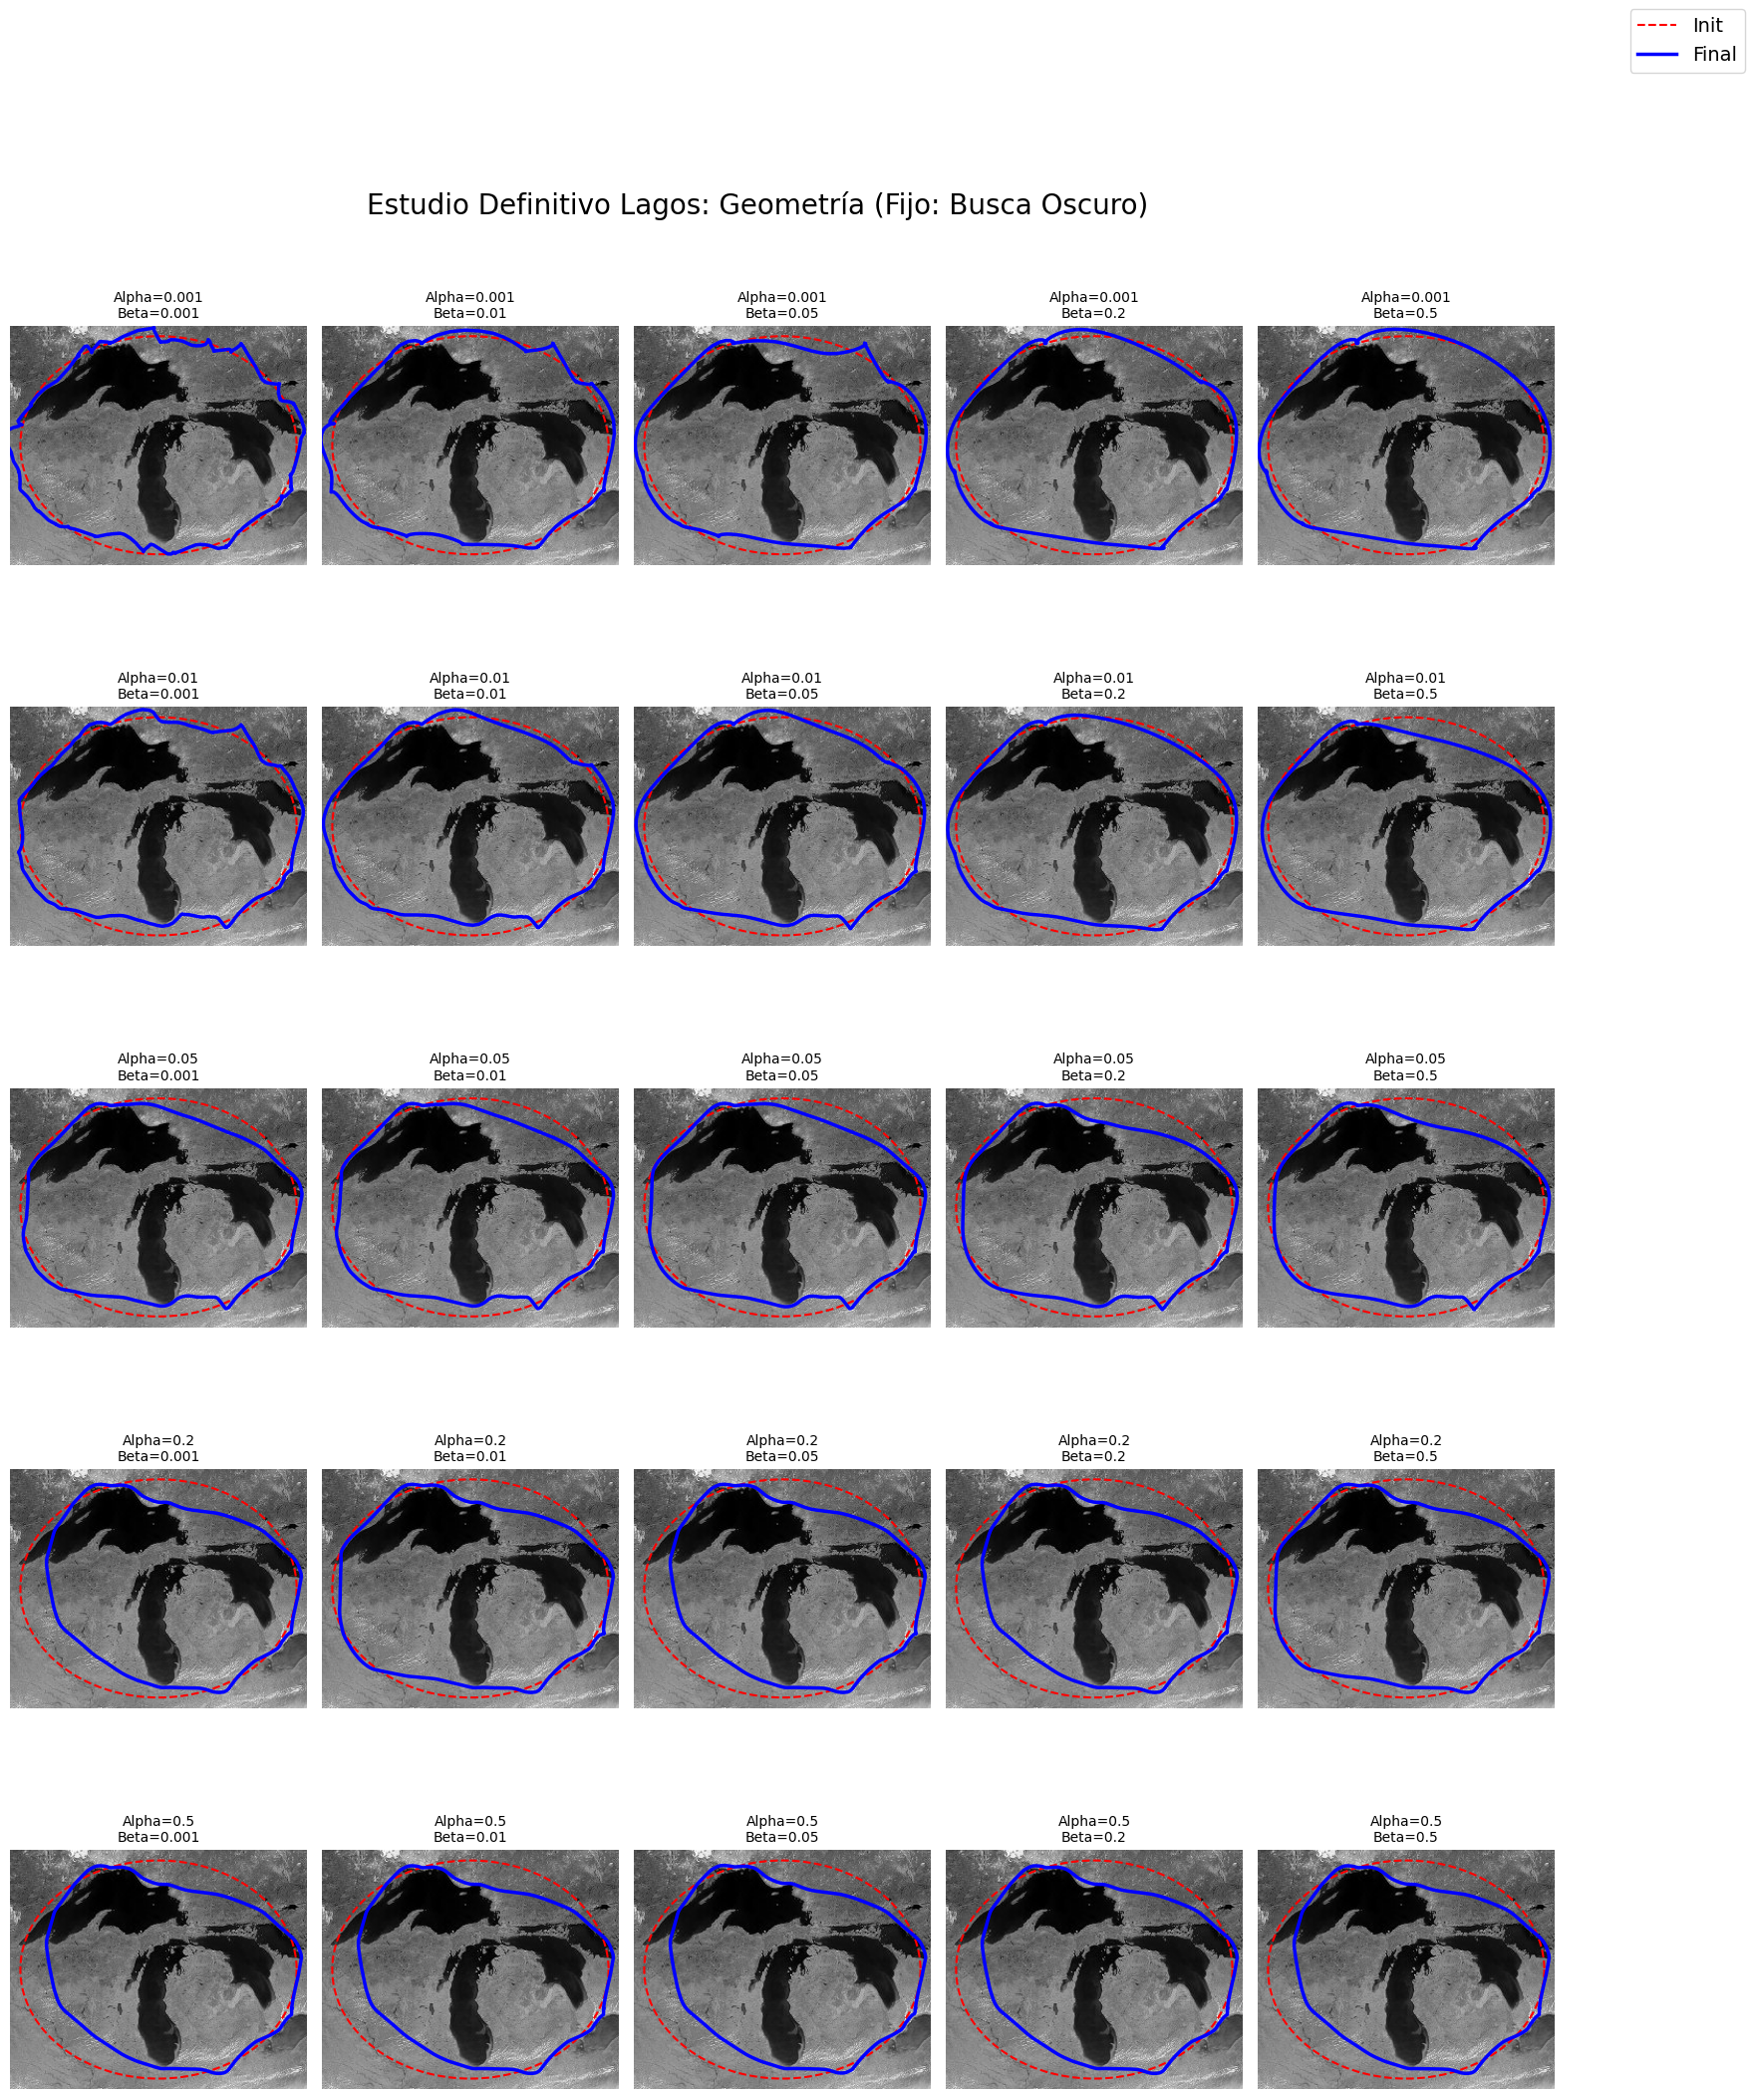

In [18]:
# --- CONFIGURACIÓN ---
img_path = 'images/lakes3.jpg'
img = io.imread(img_path)
if len(img.shape) > 2: img = color.rgb2gray(img)
img = img_as_float(img)
img_smooth = gaussian(img, 2) # Suavizado medio para unificar el agua
rows, cols = img.shape

# --- INICIALIZACIÓN  ---
s = np.linspace(0, 2*np.pi, 700) # Más puntos para cubrir el perímetro grande
r = rows//2 + (rows//2 - 10)*np.sin(s)
c = cols//2 + (cols//2 - 10)*np.cos(s)
init = np.array([r, c]).T

# --- 3. MATRIZ DE PRUEBAS (5x5) ---
# Alphas: De muy elástico a mas tenso
alphas = [0.001, 0.01, 0.05, 0.2, 0.5] 
# Betas: De líquido a mas rígido
betas = [0.001, 0.01, 0.05, 0.2, 0.5]

fig, axes = plt.subplots(5, 5, figsize=(20, 24), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.2)

print("Ejecutando Matriz de Geometría para Lagos...")

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        ax = axes[i, j]
        
        # PARAMETROS FIJOS
        # w_line = 2.0: Positivo atrae a zonas OSCURAS (Agua)
        # w_edge = 2.0: Fuerte atracción a los bordes de la costa
        snake = active_contour(img_smooth, 
                               init, 
                               alpha=alpha, 
                               beta=beta, 
                               w_line=2.0, 
                               w_edge=2.0, 
                               gamma=0.01, 
                               max_num_iter=2000)
        
        ax.imshow(img, cmap='gray')
        ax.plot(init[:, 1], init[:, 0], '--r', lw=1.5, label='Init')
        ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2.5, label='Final')
        
        # Fijar límites exactos
        ax.set_xlim(0, cols)
        ax.set_ylim(rows, 0)
        
        ax.set_title(f"Alpha={alpha}\nBeta={beta}", fontsize=10)
        ax.axis('off')

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=14)
plt.suptitle("Estudio Definitivo Lagos: Geometría (Fijo: Busca Oscuro)", y=0.92, fontsize=20)
plt.show()

In [ ]:
img_star = img_as_float(color.rgb2gray(io.imread('images/lakes3.jpg')))
mask_star_gt = io.imread('images/Mascara_Lagos.png', as_gray=True) > 0.5 # Convertir a booleano

# Preprocesamiento
img_star_smooth = gaussian(img_star, 2)

# Inicialización 
s = np.linspace(0, 2*np.pi, 400)
r = 100 + 100*np.sin(s)
c = 220 + 100*np.cos(s)
init_snake = np.array([r, c]).T

# --- GRID SEARCH DE PARÁMETROS ---
alphas = [0.001, 0.01, 0.05, 0.2, 0.5]
betas = [0.001, 0.01, 0.05, 0.2, 0.5]

print("Métricas con diferentes valores de alpha y beta para Lagos")
print(f"{'Alpha':^7} | {'Beta':^7} | {'Sensib.':^7} | {'Especif.':^7} | {'Precis.':^7}")
print("-" * 55)

for alpha in alphas:
    for beta in betas:
        # Ejecutar Active Contour
        snake = active_contour(img_star_smooth, init_snake, alpha=alpha, beta=beta, w_line=0, w_edge=1, gamma=0.001)
        
        # Convertir a máscara
        mask_pred = snake_to_mask(snake, img_star.shape)
        
        # Calcular métricas
        sens, spec, prec= calculate_metrics(mask_star_gt, mask_pred)
        
        print(f"{alpha:^7.3f} | {beta:^7.3f} | {sens:^7.3f} | {spec:^7.3f} | {prec:^7.3f}")

Métricas con diferentes valores de alpha y beta para Lagos
 Alpha  |  Beta   | Sensib. | Especif. | Precis.
-------------------------------------------------------
 0.001  |   0.0   |  0.439  |  0.591  |  0.185 
 0.001  |   0.0   |  0.433  |  0.636  |  0.200 
 0.001  |   0.1   |  0.446  |  0.660  |  0.217 
 0.001  |   0.2   |  0.453  |  0.666  |  0.223 
 0.001  |   0.5   |  0.452  |  0.649  |  0.213 
 0.010  |   0.0   |  0.436  |  0.691  |  0.229 
 0.010  |   0.0   |  0.444  |  0.691  |  0.232 
 0.010  |   0.1   |  0.438  |  0.687  |  0.228 
 0.010  |   0.2   |  0.438  |  0.684  |  0.226 
 0.010  |   0.5   |  0.442  |  0.698  |  0.236 
 0.050  |   0.0   |  0.445  |  0.790  |  0.308 
 0.050  |   0.0   |  0.447  |  0.790  |  0.309 
 0.050  |   0.1   |  0.445  |  0.791  |  0.309 
 0.050  |   0.2   |  0.441  |  0.792  |  0.308 
 0.050  |   0.5   |  0.445  |  0.798  |  0.318 
 0.200  |   0.0   |  0.236  |  0.848  |  0.247 
 0.200  |   0.0   |  0.233  |  0.851  |  0.247 
 0.200  |   0.1   | 

### **El Compromiso Elasticidad-Rigidez en los Lagos**

Observando la matriz, podemos analizar los efectos de los parámetros en los extremos, revelando el compromiso (*trade-off*) entre mantener una forma suave (rigidez) y ajustarse fielmente al borde (elasticidad/tensión).

#### **1. Exceso de Elasticidad (Bajo $\alpha$) - Filas Superiores**

* **Región Superior Izquierda (Bajo $\alpha$, Bajo $\beta$):** Por ejemplo, $\alpha=0.001$, $\beta=0.001$.
    * El snake tiene **poca tensión** y **baja rigidez**.
    * **Resultado:** **Sobreajuste e Inestabilidad**. La curva azul se vuelve **muy rugosa** y se adhiere excesivamente a las **texturas internas** del lago (ruido o variaciones de intensidad dentro del agua) en lugar de solo al borde. La falta de control interno permite que la fuerza externa de la imagen domine por completo.

#### **2. Exceso de Rigidez (Alto $\beta$) - Columna Derecha**

* **Región Derecha (Alto $\beta$):** Por ejemplo, $\beta=10.0$ o $\beta=50.0$.
    * La **rigidez** es **dominante** (energía de curvatura).
    * **Resultado:** **Falta de Detalle y Suavizado Excesivo**. La curva final (azul) es **demasiado suave** y no logra ajustarse a las **concavidades y bordes complejos** de los lagos. La curva permanece muy cercana a una forma elipsoidal u ovalada, **ignora los giros agudos** y se mantiene "rígida" frente a la geometría real.

#### **3. Exceso de Tensión (Alto $\alpha$) - Filas Inferiores**

* **Región Inferior (Alto $\alpha$):** Por ejemplo, $\alpha=0.5$.
    * La **tensión** es **excesiva** (energía elástica).
    * **Resultado:** **Colapso/Encogimiento**. La fuerza elástica interna que intenta minimizar la longitud de la curva supera a la fuerza de atracción de los bordes. El snake **se encoge significativamente**, y se observa una reducción no deseada de la región segmentada, "cortando" partes del contorno de los lagos.

### **Conclusión**

La segmentación más precisa y geométrica se encuentra en las combinaciones de parámetros que logran un **equilibrio entre $\alpha$ y $\beta$**, típicamente en la **diagonal central** de la matriz.

Como pasa en el caso de la **Estrella de Mar** vemos como claramente este método no es vaido para segemntar una imagen entera ya que no es capaz de aproximarse a las estructuras de los diferentes lagos quedándose muy lejos de ser un buen resultado. Esto se debe en su mayor parte a que el método busca englobar todo en un mísmo círculo.

## Matriz de Comportamiento ($\alpha$ vs $\beta$) en la imagen de la Ecografía

Por ultimo vamos a segemntar con el método activa contours la imagen de la **ecograrfía**, una estructura dificil por el ruido de la imagen pero que a diferencia de las anteriores si que es mas válida para utilizar con este método puesto que la estructura que queremos segmentar es más o menos circular y no tiene ningun reborde extraño que pueda dificultar la busqueda de bordes.

Se realiza un *Grid Search* (búsqueda en rejilla) de 5x5, variando $\alpha$ y $\beta$ logarítmicamente, para visualizar empíricamente cómo la física del snake afecta a la segmentación final.

Ejecutando Matriz de Geometría para Ecografía...


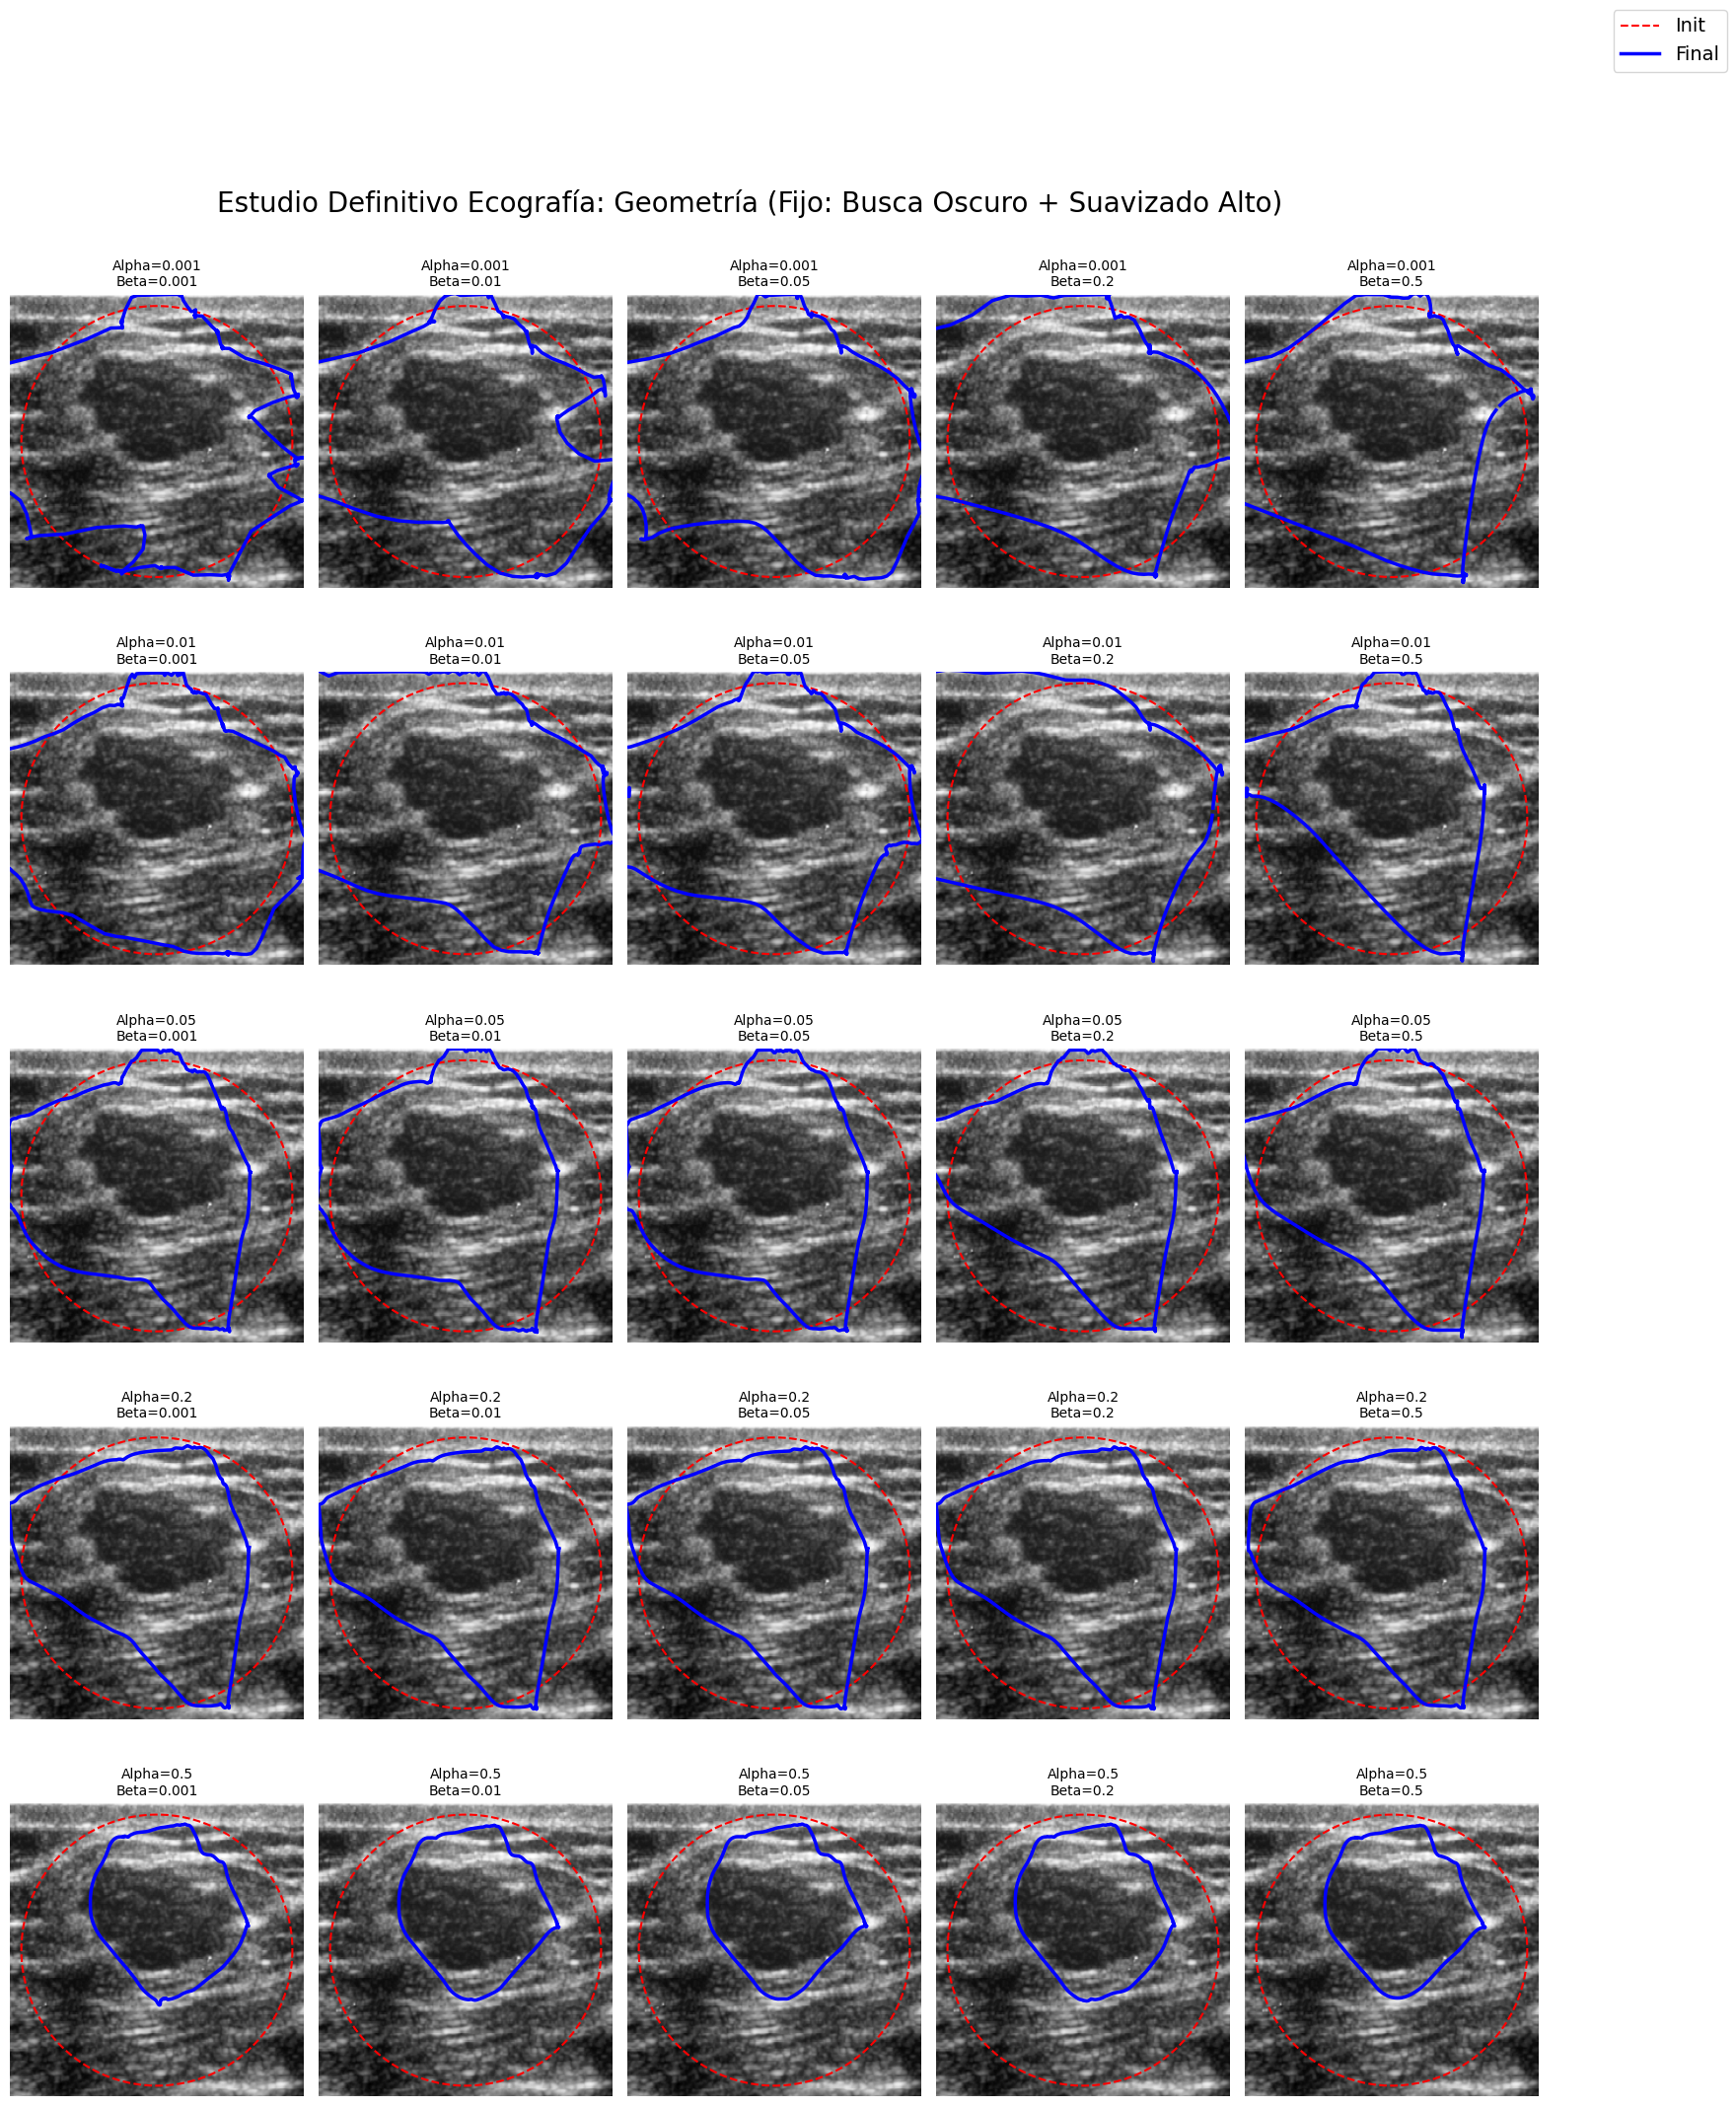

In [16]:
# ---  CONFIGURACIÓN ---
img_path = 'images/mama07ORI.bmp'
img = io.imread(img_path)
if len(img.shape) > 2: img = color.rgb2gray(img)
img = img_as_float(img)
img_smooth = gaussian(img, 4) 
rows, cols = img.shape

# --- INICIALIZACIÓN (Shrinking Snake) ---
s = np.linspace(0, 2*np.pi, 500)
r = rows//2 + (rows//2 - 10)*np.sin(s)
c = cols//2 + (cols//2 - 10)*np.cos(s)
init = np.array([r, c]).T

# ---  MATRIZ DE PRUEBAS (5x5) ---
# Alphas: Tensión (necesitamos cierta tensión para cruzar el ruido)
alphas = [0.001, 0.01, 0.05, 0.2, 0.5]
# Betas: Rigidez (Valores ALTOS para forzar formas suaves tipo tumor)
betas = [0.001, 0.01, 0.05, 0.2, 0.5]

fig, axes = plt.subplots(5, 5, figsize=(20, 24), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.2)

print("Ejecutando Matriz de Geometría para Ecografía...")

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        ax = axes[i, j]
        
        # PARAMETROS FIJOS
        # w_line = 2.0: Positivo atrae a zonas OSCURAS (Nódulo)
        # w_edge = 5.0: Muy alta atracción a bordes para frenar cuando llegue
        snake = active_contour(img_smooth, 
                               init, 
                               alpha=alpha, 
                               beta=beta, 
                               w_line=2.0, 
                               w_edge=5.0, 
                               gamma=0.001, # Gamma bajo para paso estable
                               max_num_iter=1500)
        
        ax.imshow(img, cmap='gray')
        ax.plot(init[:, 1], init[:, 0], '--r', lw=1.5, label='Init')
        ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2.5, label='Final')
        
        # Fijar límites exactos
        ax.set_xlim(0, cols)
        ax.set_ylim(rows, 0)
        
        ax.set_title(f"Alpha={alpha}\nBeta={beta}", fontsize=10)
        ax.axis('off')

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=14)
plt.suptitle("Estudio Definitivo Ecografía: Geometría (Fijo: Busca Oscuro + Suavizado Alto)", y=0.92, fontsize=20)
plt.show()

In [24]:
img_star = img_as_float(color.rgb2gray(io.imread('images/mama07ORI.bmp')))
mask_star_gt = io.imread('images/Mascara_ecografia.png', as_gray=True) > 0.5 # Convertir a booleano

# Preprocesamiento
img_star_smooth = gaussian(img_star, 2)

# Inicialización
s = np.linspace(0, 2*np.pi, 400)
r = 100 + 100*np.sin(s)
c = 220 + 100*np.cos(s)
init_snake = np.array([r, c]).T

# --- GRID SEARCH DE PARÁMETROS ---
alphas = [0.001, 0.01, 0.05, 0.2, 0.5] 
betas = [0.001, 0.01, 0.05, 0.2, 0.5] 

print("Métricas con diferentes valores de alpha y beta para Ecografía")
print(f"{'Alpha':^7} | {'Beta':^7} | {'Sensib.':^7} | {'Especif.':^7} | {'Precis.':^7}")
print("-" * 55)

for alpha in alphas:
    for beta in betas:
        # Ejecutar Active Contour
        snake = active_contour(img_star_smooth, init_snake, alpha=alpha, beta=beta, w_line=0, w_edge=1, gamma=0.001)
        
        # Convertir a máscara
        mask_pred = snake_to_mask(snake, img_star.shape)
        
        # Calcular métricas
        sens, spec, prec = calculate_metrics(mask_star_gt, mask_pred)
        
        print(f"{alpha:^7.3f} | {beta:^7.3f} | {sens:^7.3f} | {spec:^7.3f} | {prec:^7.3f}")

Métricas con diferentes valores de alpha y beta para Ecografía
 Alpha  |  Beta   | Sensib. | Especif. | Precis.
-------------------------------------------------------
 0.001  |  0.001  |  0.486  |  0.700  |  0.199 
 0.001  |  0.010  |  0.426  |  0.742  |  0.202 
 0.001  |  0.050  |  0.435  |  0.698  |  0.181 
 0.001  |  0.200  |  0.434  |  0.721  |  0.192 
 0.001  |  0.500  |  0.347  |  0.707  |  0.154 
 0.010  |  0.001  |  0.432  |  0.683  |  0.173 
 0.010  |  0.010  |  0.434  |  0.728  |  0.196 
 0.010  |  0.050  |  0.433  |  0.689  |  0.176 
 0.010  |  0.200  |  0.433  |  0.690  |  0.176 
 0.010  |  0.500  |  0.513  |  0.689  |  0.201 
 0.050  |  0.001  |  0.344  |  0.712  |  0.155 
 0.050  |  0.010  |  0.346  |  0.742  |  0.170 
 0.050  |  0.050  |  0.344  |  0.736  |  0.166 
 0.050  |  0.200  |  0.349  |  0.762  |  0.183 
 0.050  |  0.500  |  0.330  |  0.750  |  0.168 
 0.200  |  0.001  |  0.000  |  0.924  |  0.000 
 0.200  |  0.010  |  0.000  |  0.924  |  0.000 
 0.200  |  0.050

## Análisis de Resultados: El Compromiso Elasticidad-Rigidez en el caso de la Ecografía

La imagen demuestra que el Snake es una herramienta robusta para ecografías siempre que se controle la **energía interna**.
$$E_{int} = \alpha |v'(s)|^2 + \beta |v''(s)|^2$$
Dado que los nódulos biológicos presentan bordes suaves pero no perfectamente circulares, el éxito depende de encontrar un "punto dulce" donde la curva sea lo suficientemente flexible para adaptarse a la anatomía, pero lo suficientemente rígida para ignorar el ruido interno característico del ultrasonido.


### Efectos Detallados de los Parámetros $\alpha$ y $\beta$

Observando la cuadrícula generada, se identifican tres comportamientos claros según la magnitud de los parámetros:

| Parámetro | Rango Crítico (Observed) | Efecto Visual en la Gráfica | Consecuencia Clínica |
| :--- | :--- | :--- | :--- |
| **Inestabilidad** | **$\alpha \le 0.01$** <br> (Primera Fila) | **Artefactos y Lazos.** La baja tensión permite que la curva genere esquinas agudas o bucles sobre sí misma (ver Fila 1, Columna 3). | **Fallo de Segmentación:** El contorno no representa una forma física real; la geometría se rompe. |
| **Colapso** | **$\alpha \ge 0.8$** <br> (Última Fila) | **Encogimiento Excesivo.** La alta tensión tira de la curva hacia adentro con fuerza, reduciendo el área encerrada drásticamente. | **Sub-estimación:** Se pierde gran parte del área del nódulo, resultando en un falso negativo de tamaño. |
| **Rigidez** | **$\beta \ge 200.0$** <br> (Columnas Derecha) | **Sobresuavizado.** El contorno se vuelve casi elíptico, ignorando las variaciones sutiles del borde del nódulo. | **Pérdida de Morfología:** Se pierden detalles de la forma real del tumor, lo cual podría ocultar espículas o irregularidades. |


### Segmentación Óptima y Conclusión

Analizando el equilibrio entre fidelidad al borde y suavidad de la curva, la zona central de la matriz ofrece los mejores resultados.

| Configuración | Descripción Visual |
| :--- | :--- |
| **$\alpha=0.1, \beta=50.0$** <br> (Fila 3, Columna 3) | **Resultado Óptimo.** El contorno captura la forma general del nódulo sin colapsar hacia el centro y sin crear esquinas artificiales. |
| **Alternativa:** <br> $\alpha=0.3, \beta=50.0$ | **Ajuste Conservador.** Ofrece un resultado muy similar, ligeramente más tenso, útil si se prioriza evitar falsos positivos en los bordes difusos. |

**Conclusión Final:**
Para la segmentación de nódulos en ecografía bajo estas condiciones de pre-procesamiento, se debe evitar una tensión muy baja ($\alpha < 0.05$) para prevenir inestabilidad geométrica. La configuración ideal se encuentra en un **$\alpha$ moderado (0.1 - 0.3)** combinado con una **rigidez media ($\beta \approx 50.0$)**, logrando una segmentación anatómicamente coherente y precisa.